In [1]:
# Install and import packages for TDA (ripser, persim, gudhi), optimal transport (POT), and Gower distance (for mixed continuous/categorical real patient data)

!pip install ripser persim scikit-learn
!pip install gudhi
!pip install gudhi POT
!pip install gower
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.special import logsumexp
import matplotlib.pyplot as plt
from ripser import ripser
from ripser import Rips
from persim import wasserstein, plot_diagrams
from persim import PersLandscapeApprox
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
import gudhi
from gudhi.wasserstein import wasserstein_distance
import ot
import gower

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.8 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=88e69c5365acd3e9677160e8064659cbc231c2b31a9854f3efeb8f8b39d91446
  Stored in directory: /root/.cache/pip/wheels/b3/32/77/3c78fadb9f917d5a5546ed0409574012401a83c544ec95999a
Successfully built hopcroftkarp
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 62.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 63.2 MB/s eta 0:00:00


In [2]:
# Upload the TCGA patient covariates CSV file from local disk (Colab file picker)

from google.colab import files
uploaded = files.upload()

Saving tcga_patient_covariates.csv to tcga_patient_covariates.csv


In [3]:
# Load the TCGA patient covariates and map inconsistent hospital ('site') name spellings onto one canonical name per hospital

data = pd.read_csv("tcga_patient_covariates.csv")

# remove stray whitespace (e.g. "UNC " vs "UNC")
data["site_clean"] = data["site"].str.strip()

site_map = {
    "MD Anderson": "MD Anderson Cancer Center",
    "University of Texas MD Anderson Cancer Center": "MD Anderson Cancer Center",

    "Mayo": "Mayo Clinic",
    "Mayo Clinic Arizona": "Mayo Clinic",
    "Mayo Clinic - Rochester": "Mayo Clinic",
    "Mayo Clinic Rochester": "Mayo Clinic",

    "ABS IUPUI": "ABS - IUPUI",
    "BLN Baylor": "BLN - Baylor",
    "BLN UT Southwestern Medical Center at Dallas": "BLN - UT Southwestern Medical Center at Dallas",

    "University Of Michigan": "University of Michigan",
    "Michigan University": "University of Michigan",
    "International Genomics Conosrtium": "International Genomics Consortium",
    "Greenville Health Systems": "Greenville Health System",

    "St. Joseph's Hospital Arizona": "St. Joseph's Hospital (AZ)",
    "St. Joseph's Hospital AZ": "St. Joseph's Hospital (AZ)",
    "St. Joseph's Medical Center-(MD)": "St. Joseph's Medical Center (MD)",
    "St Joseph's Medical Center (MD)": "St. Joseph's Medical Center (MD)",

    "Washington University St. Louis": "Washington University",
    "Washington University - St. Louis": "Washington University",

    "Memorial Sloan Kettering Cancer Centre": "Memorial Sloan Kettering",
    "Memorial Sloan Kettering Cancer Center": "Memorial Sloan Kettering",
    "MSKCC": "Memorial Sloan Kettering",

    "University Health Network, Toronto": "University Health Network",
    "Hartford": "Hartford Hospital",
    "UCSF": "University of California San Francisco",
    "Duke University": "Duke",
    "Vanderbilt University": "Vanderbilt",
    "Yale University": "Yale",
    "Roswell": "Roswell Park",
    "Cleveland Clinic Foundation": "Cleveland Clinic",
    "Christiana Care": "Christiana Healthcare",
    "Gundersen Lutheran Health System": "Gundersen Lutheran",
    "The Ohio State University": "Ohio State University",
    "UNC": "University of North Carolina",
    "Fox Chase Cancer Center": "Fox Chase",
    "ILSBIO": "ILSBio",
    "ILSbio": "ILSBio",
    "Proteogenex, Inc": "Proteogenex, Inc.",
    "Ontario Institute for Cancer Research (OICR)": "Ontario Institute for Cancer Research",
    "Ontario Institute for Cancer Research (OICR)/Ottawa": "Ontario Institute for Cancer Research",
    "Thoraxklinik at University Hospital Heidelberg": "Thoraxklinik",
    "BC Cancer Agency": "British Columbia Cancer Agency",
    "Emory University - Winship Cancer Inst.": "Emory University",
    "St. University of Colorado Denver": "University of Colorado Denver",
    "University of Kansas Medical Center": "University of Kansas",
}


data["site_clean"] = data["site_clean"].replace(site_map)
data["site_clean"] = data["site_clean"].replace("", np.nan)

In [5]:
# Restrict to the 6 largest hospitals by patient count, clean race/sex categories, and collapse detailed cancer stages into Stage I-IV or Undisclosed

N_HOSPITALS = 6

site_counts = data["site_clean"].value_counts()
qualifying_sites = site_counts.head(N_HOSPITALS).index

data = data[data["site_clean"].isin(qualifying_sites)].copy()
print(f"Top {N_HOSPITALS} hospitals by patient count:")
print(site_counts.head(N_HOSPITALS))

# Clean race and sex
data["race"] = data["race"].replace(
    {"not reported": "Unreported", "Unknown": "Unreported", "": "Unreported"}
).fillna("Unreported")
data["race"] = data["race"].replace(
    {"american indian or alaska native": "Other", "native hawaiian or other pacific islander": "Other"}
)
data["sex"] = data["sex"].replace({"": "Unreported", "unknown": "Unreported"}).fillna("Unreported")

# Stage mapping
stage_map = {
    "Stage IA": "Stage I", "Stage IB": "Stage I", "Stage IB1": "Stage I", "Stage IB2": "Stage I",
    "Stage IC": "Stage I", "Stage I": "Stage I",
    "Stage IIA": "Stage II", "Stage IIA1": "Stage II", "Stage IIA2": "Stage II", "Stage IIa": "Stage II",
    "Stage IIB": "Stage II", "Stage IIb": "Stage II", "Stage IIC": "Stage II", "Stage II": "Stage II",
    "Stage IIIA": "Stage III", "Stage IIIB": "Stage III", "Stage IIIC": "Stage III",
    "Stage IIIC1": "Stage III", "Stage IIIC2": "Stage III", "Stage III": "Stage III",
    "Stage IVA": "Stage IV", "Stage IVB": "Stage IV", "Stage IVC": "Stage IV", "Stage IV": "Stage IV",
    "Stage X": "Undisclosed", "Stage 0": "Undisclosed",
}

unmapped = data.loc[
    ~data["stage"].isin(stage_map.keys()) & data["stage"].notna() & (data["stage"] != ""),
    "stage",
].unique()
if len(unmapped) > 0:
    print("Warning: unmapped stage values found:", unmapped)

data["stage_grouped"] = data["stage"].map(stage_map)
data.loc[data["stage"].isna() | (data["stage"] == ""), "stage_grouped"] = "Undisclosed"

stage_order = {"Stage I": 1, "Stage II": 2, "Stage III": 3, "Stage IV": 4}
data["stage_ordinal"] = data["stage_grouped"].map(stage_order)

# Final filtered dataset
grouped_data = data[
    ~(
        (data["sex"] == "Unreported")
        | (data["stage_grouped"] == "Undisclosed")
        | data["stage_grouped"].isna()
    )
].copy()

grouped_data = grouped_data[
    ["site_clean", "cancer_type", "age_at_diagnosis", "sex", "race",
     "stage", "stage_grouped", "stage_ordinal", "year_of_diagnosis"]
]

grouped_data.head()

Top 6 hospitals by patient count:
site_clean
Memorial Sloan Kettering             817
University of Pittsburgh             795
MD Anderson Cancer Center            649
International Genomics Consortium    554
Asterand                             525
Mayo Clinic                          522
Name: count, dtype: int64


,site_clean,cancer_type,age_at_diagnosis,sex,race,stage,stage_grouped,stage_ordinal,year_of_diagnosis
321,University of Pittsburgh,Bladder Urothelial Carcinoma,75.4,male,white,Stage III,Stage III,3.0,2007.0
322,University of Pittsburgh,Bladder Urothelial Carcinoma,70.0,female,white,Stage III,Stage III,3.0,2009.0
323,University of Pittsburgh,Bladder Urothelial Carcinoma,75.7,male,white,Stage II,Stage II,2.0,1999.0
324,University of Pittsburgh,Bladder Urothelial Carcinoma,72.4,male,Unreported,Stage III,Stage III,3.0,2003.0
325,University of Pittsburgh,Bladder Urothelial Carcinoma,75.4,male,white,Stage III,Stage III,3.0,2003.0


In [6]:
# Assign each hospital a numbered label, keep only the covariates needed for the TDA/raw-data tests, drop rows with any missing values, and encode sex numerically

grouped_data = grouped_data[[ "age_at_diagnosis", "year_of_diagnosis", "sex", "race", "cancer_type", "stage_ordinal", "site_clean"]]
# Assign each hospital a numbered label (Hospital 1, Hospital 2, ...)
hospital_ids = {site: f"Hospital {i+1}" for i, site in enumerate(grouped_data["site_clean"].unique())}
grouped_data["hospital_id"] = grouped_data["site_clean"].map(hospital_ids)

grouped_data = grouped_data[
    ["age_at_diagnosis", "year_of_diagnosis", "sex", "race", "cancer_type",
     "stage_ordinal", "site_clean", "hospital_id"]
]

print(hospital_ids)
grouped_data.head()

grouped_data_clean = grouped_data.dropna(subset=["age_at_diagnosis", "year_of_diagnosis", "sex", "race", "cancer_type", "stage_ordinal","hospital_id"]).copy()
grouped_data_clean["sex"] = grouped_data_clean["sex"].map({"male": 0, "female": 1})

print(grouped_data_clean["site_clean"].value_counts())

{'University of Pittsburgh': 'Hospital 1', 'Memorial Sloan Kettering': 'Hospital 2', 'Asterand': 'Hospital 3', 'MD Anderson Cancer Center': 'Hospital 4', 'International Genomics Consortium': 'Hospital 5', 'Mayo Clinic': 'Hospital 6'}
site_clean
Memorial Sloan Kettering             665
University of Pittsburgh             660
Asterand                             493
MD Anderson Cancer Center            487
Mayo Clinic                          470
International Genomics Consortium    437
Name: count, dtype: int64


In [7]:
# Compute a Gower distance matrix per hospital (handles the mix of continuous and categorical covariates), then sanity-check for NaNs before running Ripser

gower_matrices = {}

for hospital in grouped_data_clean["hospital_id"].unique():
    subset = grouped_data_clean[grouped_data_clean["hospital_id"] == hospital]
    subset_features = subset.drop(columns=["hospital_id"])
    gower_matrices[hospital] = gower.gower_matrix(subset_features)

# Sanity check — confirm zero NaNs before running Ripser
for h, mat in gower_matrices.items():
    print(h, "NaN:", np.isnan(mat).sum(), "shape:", mat.shape)

# Example: access the matrix for a specific hospital
X_1, X_2, X_3, X_4, X_5, X_6 = (gower_matrices[f"Hospital {i}"] for i in range(1, 7))


Hospital 1 NaN: 0 shape: (660, 660)
Hospital 2 NaN: 0 shape: (665, 665)
Hospital 3 NaN: 0 shape: (493, 493)
Hospital 4 NaN: 0 shape: (487, 487)
Hospital 5 NaN: 0 shape: (437, 437)
Hospital 6 NaN: 0 shape: (470, 470)


In [8]:
# Compute persistence diagrams
def get_diagrams(X, max_dim=1):
    result = ripser(X, maxdim=max_dim, distance_matrix=True)
    return result['dgms']

dgms_1 = get_diagrams(X_1)
dgms_2 = get_diagrams(X_2)
dgms_3 = get_diagrams(X_3)
dgms_4 = get_diagrams(X_4)
dgms_5 = get_diagrams(X_5)
dgms_6 = get_diagrams(X_6)

In [9]:
# Flag age-at-diagnosis outliers within each (hospital, cancer type) group using the IQR rule, skipping groups with fewer than 5 patients

def iqr_outlier_mask(x, k=1.5):
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (x < lower) | (x > upper)

grouped_data_clean["age_outlier"] = (
    grouped_data_clean.groupby(["hospital_id", "cancer_type"])["age_at_diagnosis"]
    .transform(lambda x: iqr_outlier_mask(x) if len(x) >= 5 else pd.Series(False, index=x.index))
)


In [10]:
# Remove flagged age outliers, then recompute each hospital's Gower distance matrix and persistence diagrams on the cleaned data

grouped_data_noout = grouped_data_clean[~grouped_data_clean["age_outlier"]].copy()

gower_matrices_noout = {}
for hospital in grouped_data_noout["hospital_id"].unique():
    subset = grouped_data_noout[grouped_data_noout["hospital_id"] == hospital]
    subset_features = subset.drop(columns=["hospital_id", "age_outlier"])
    gower_matrices_noout[hospital] = gower.gower_matrix(subset_features)

X_1_no, X_2_no, X_3_no, X_4_no, X_5_no, X_6_no = (
    gower_matrices_noout[f"Hospital {i}"] for i in range(1, 7)
)

dgms_1_no = get_diagrams(X_1_no)
dgms_2_no = get_diagrams(X_2_no)
dgms_3_no = get_diagrams(X_3_no)
dgms_4_no = get_diagrams(X_4_no)
dgms_5_no = get_diagrams(X_5_no)
dgms_6_no = get_diagrams(X_6_no)

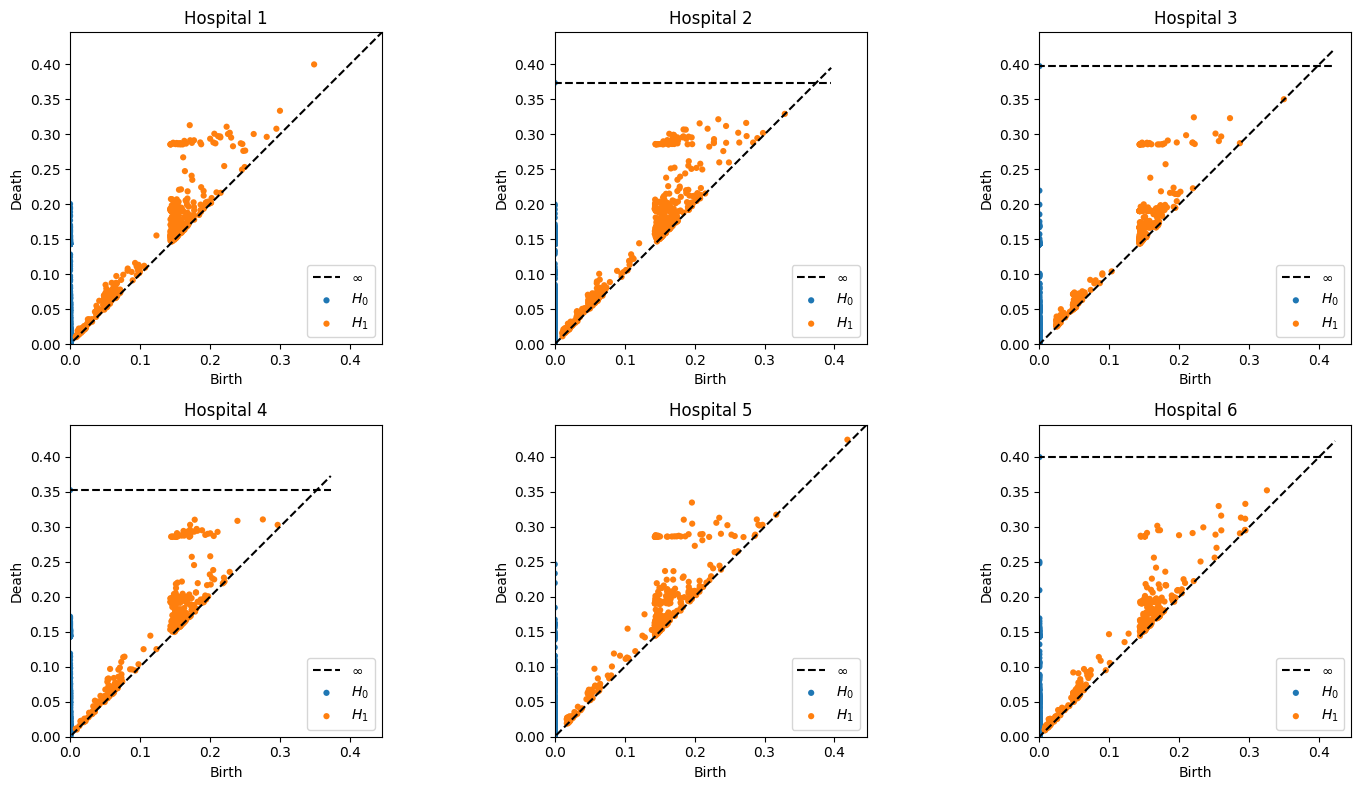

In [11]:
# Plot persistence diagrams
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

diagrams_list = [dgms_1, dgms_2, dgms_3, dgms_4, dgms_5, dgms_6]
titles = ["Hospital 1", "Hospital 2", "Hospital 3", "Hospital 4", "Hospital 5", "Hospital 6"]

# Compute a shared axis limit across all six diagrams
all_finite_vals = []
for dgms in diagrams_list:
    for dgm in dgms:
        finite = dgm[np.isfinite(dgm[:, 1])]
        if finite.size > 0:
            all_finite_vals.append(finite.max())
axis_max = max(all_finite_vals) * 1.05

for ax, dgms, title in zip(axes, diagrams_list, titles):
    plt.sca(ax)
    plot_diagrams(dgms, show=False)
    ax.set_title(title)
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)

plt.tight_layout()
plt.show()

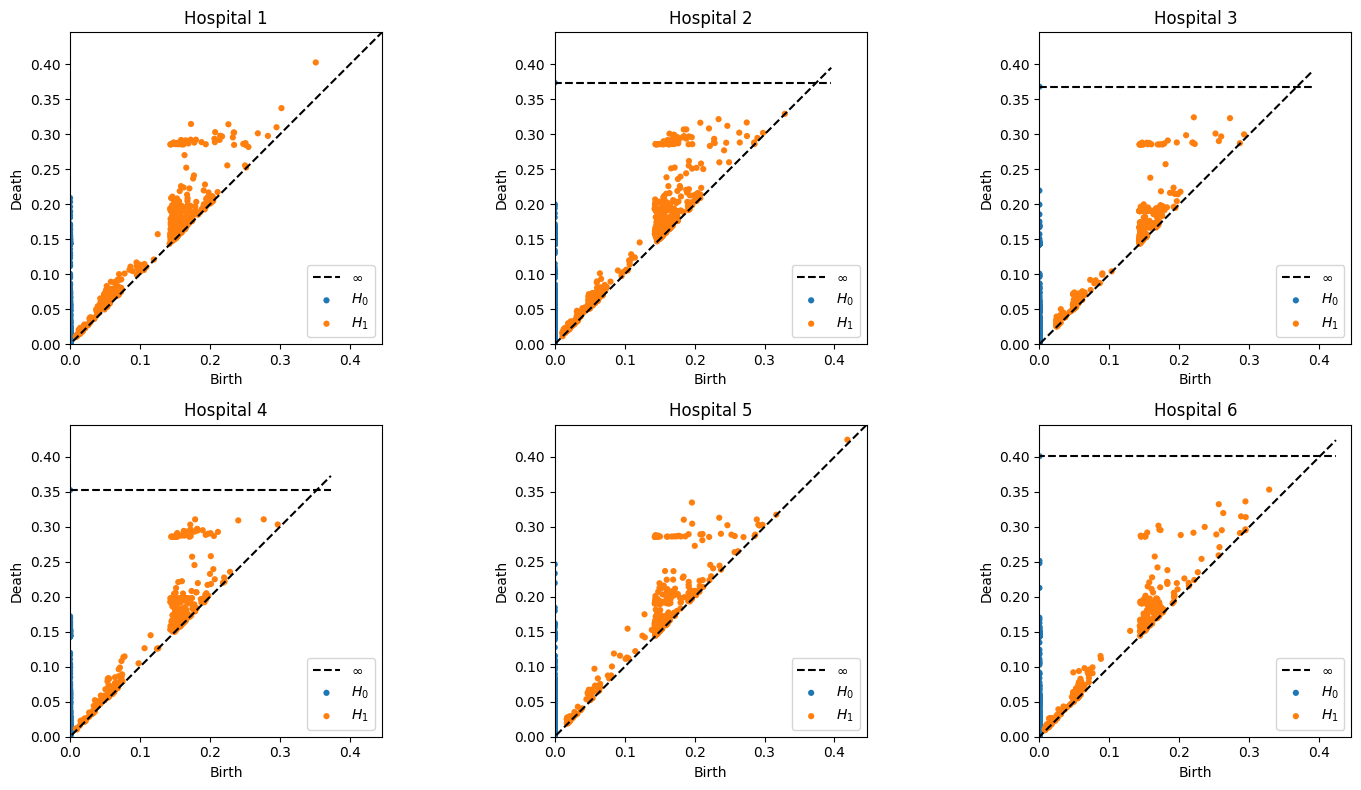

In [12]:
# Plot persistence diagrams (outliers removed)

# Plot persistence diagrams
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

diagrams_list_no = [dgms_1_no, dgms_2_no, dgms_3_no, dgms_4_no, dgms_5_no, dgms_6_no]
titles = ["Hospital 1", "Hospital 2", "Hospital 3", "Hospital 4", "Hospital 5", "Hospital 6"]

# Compute a shared axis limit across all six diagrams
all_finite_vals = []
for dgms in diagrams_list_no:
    for dgm in dgms:
        finite = dgm[np.isfinite(dgm[:, 1])]
        if finite.size > 0:
            all_finite_vals.append(finite.max())
axis_max = max(all_finite_vals) * 1.05

for ax, dgms, title in zip(axes, diagrams_list_no, titles):
    plt.sca(ax)
    plot_diagrams(dgms, show=False)
    ax.set_title(title)
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)

plt.tight_layout()
plt.show()

In [13]:
# Compare each hospital's full-data vs. outlier-removed persistence diagrams via bottleneck distance, to check how much the flagged outliers affect topology

from persim import bottleneck

def compare_diagrams(dgms_full, dgms_noout, dim=1):
    return bottleneck(dgms_full[dim], dgms_noout[dim])

results = {}
all_dgms_full = [dgms_1, dgms_2, dgms_3, dgms_4, dgms_5, dgms_6]
all_dgms_noout = [dgms_1_no, dgms_2_no, dgms_3_no, dgms_4_no, dgms_5_no, dgms_6_no]

for i, (full, noout) in enumerate(zip(all_dgms_full, all_dgms_noout), start=1):
    b0 = compare_diagrams(full, noout, dim=0)
    b1 = compare_diagrams(full, noout, dim=1)
    results[f"Hospital {i}"] = {"bottleneck_H0": b0, "bottleneck_H1": b1}

pd.DataFrame(results).T

/usr/local/lib/python3.13/dist-packages/persim/bottleneck.py:55: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/persim/bottleneck.py:64: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(


,bottleneck_H0,bottleneck_H1
Hospital 1,0.008521,0.011009
Hospital 2,0.002870,0.004006
Hospital 3,0.009663,0.005280
Hospital 4,0.022854,0.011928
Hospital 5,0.012535,0.013489
Hospital 6,0.008980,0.023550


In [14]:
# Compute distance matrix, less computationally expensive
def precompute_distances(diagrams, dim=1, order=2, internal_p=2):
    m = len(diagrams)
    D = np.zeros((m, m))
    for i in range(m):
        for j in range(i+1, m):
            if order == np.inf:
                d = gudhi.bottleneck_distance(diagrams[i][dim], diagrams[j][dim])
            else:
                d = wasserstein_distance(diagrams[i][dim], diagrams[j][dim],
                    order=order, internal_p=internal_p)
            D[i, j] = d
            D[j, i] = d
    return D

In [15]:
# Sample persistence diagrams without replacement to ensure independence
# (operates on a precomputed Gower distance matrix rather than raw covariates, so subsampling slices out the corresponding square submatrix)

def sample_diagrams_nonoverlapping(X, n_subsamples, subsample_size, seed=0):
    rng = np.random.default_rng(seed)
    n = len(X)
    assert n_subsamples * subsample_size <= n, (
        f"Not enough patients: need {n_subsamples * subsample_size}, have {n}"
    )
    idx_all = rng.permutation(n)
    diagrams = []
    for i in range(n_subsamples):
        idx = idx_all[i * subsample_size : (i + 1) * subsample_size]
        sub_dist = X[np.ix_(idx, idx)]  # square submatrix for a distance matrix
        dgms = get_diagrams(sub_dist, max_dim=1)
        diagrams.append(dgms)
    return diagrams

In [16]:
# Compute Inco-variance as defined in Krebs and Rademacher paper (Section 4.1)

# As defined in paper
def inco_variance_from_matrix(D):
    m = len(D)
    return np.sum(0.5 * D**2) / (m * (m - 1))

In [17]:
# Check Wasserstein fourth moment convergence

def fourth_moment_check(D):
    fourth_moment_estimate = np.mean(D**4)
    return fourth_moment_estimate

In [18]:
# Assess fourth-moment convergence for each hospital over 100 iterations, resampling diagrams directly from each hospital's own Gower distance matrix

hospitals = ["Hospital 1", "Hospital 2", "Hospital 3", "Hospital 4", "Hospital 5", "Hospital 6"]

fourth_moments = {h: [] for h in hospitals}

i = 0
while i < 100:
    for h in hospitals:
        X_h = gower_matrices[h]
        dgms_h_samples = sample_diagrams_nonoverlapping(X_h, n_subsamples=8, subsample_size=50)
        W_h = precompute_distances(dgms_h_samples, dim=1, order=2, internal_p=np.inf)
        fourth_moments[h].append(fourth_moment_check(W_h))
    i += 1

for h in hospitals:
    vals = fourth_moments[h]
    print(f"{h}: mean={np.mean(vals):.2f}, std={np.std(vals):.2f}, "
          f"min={min(vals):.2f}, max={max(vals):.2f}")

Hospital 1: mean=0.00, std=0.00, min=0.00, max=0.00
Hospital 2: mean=0.00, std=0.00, min=0.00, max=0.00
Hospital 3: mean=0.00, std=0.00, min=0.00, max=0.00
Hospital 4: mean=0.00, std=0.00, min=0.00, max=0.00
Hospital 5: mean=0.00, std=0.00, min=0.00, max=0.00
Hospital 6: mean=0.00, std=0.00, min=0.00, max=0.00


In [19]:
# Compute F joint loss as defined in Robinson and Turner (Section 4.2)

def F_from_distance_matrix(D, idx_groups, q=2):
    total = 0.0
    for idx_m in idx_groups:
        n_m = len(idx_m)
        D_m = D[np.ix_(idx_m, idx_m)]
        sigma2_m = np.sum(D_m**q)
        total += sigma2_m / (2 * n_m * (n_m - 1))
    return total

In [20]:
# Use F joint loss to compute permutation test, Robinson and Turner (Section 4.2)

def permutation_test(dgms_samples_list, n_perms=1000, dim=1, order=2, internal_p=2, q=2, seed=0):
    rng = np.random.default_rng(seed)

    pooled_dgms = sum(dgms_samples_list, [])
    group_sizes = [len(d) for d in dgms_samples_list]
    labels = np.concatenate([
        np.full(n_m, m) for m, n_m in enumerate(group_sizes)
    ])

    D_pooled = precompute_distances(pooled_dgms, dim, order, internal_p)

    idx_groups_obs = [np.where(labels == m)[0] for m in range(len(dgms_samples_list))]
    F_L_obs = F_from_distance_matrix(D_pooled, idx_groups_obs, q=q)

    Z = 1
    for i in range(1, n_perms):
        shuffled_labels = rng.permutation(labels)
        idx_groups_perm = [np.where(shuffled_labels == m)[0] for m in range(len(dgms_samples_list))]
        F_L = F_from_distance_matrix(D_pooled, idx_groups_perm, q=q)
        if F_L <= F_L_obs:
            Z += 1

    return Z / (n_perms + 1)

In [21]:
# Using python package PersLandscapeApprox developed following Bubekin's paper we compute the landscape for each persistence diagram
# stack_and_pad ensures all landscape matrices have the same dimension so landscapes can be compared

def safe_landscape_values(dgms, hom_deg, num_steps, start, stop):
    values_list = []
    for dgm in dgms:
        sub_arr = np.asarray(dgm[hom_deg])
        finite = sub_arr[np.isfinite(sub_arr).all(axis=1)] if sub_arr.size > 0 else sub_arr
        if finite.shape[0] == 0:
            values_list.append(np.zeros((1, num_steps)))
        else:
            pl = PersLandscapeApprox(dgms=dgm, hom_deg=hom_deg, num_steps=num_steps,
                                      start=start, stop=stop)
            values_list.append(pl.values)
    return values_list


def stack_and_pad(values_list, num_steps):
    K = max(v.shape[0] for v in values_list)
    padded = [np.vstack([v, np.zeros((K - v.shape[0], num_steps))]) if v.shape[0] < K else v
              for v in values_list]
    return np.array(padded)

In [22]:
# Stack per-sample landscapes into a common array and define the between-group landscape test statistic:
# for each group, sum the squared distance between its mean landscape and the overall mean landscape,
# where the sum over the landscape's function-value axis approximates ∫(diff)^2 via a Riemann sum with step dt,
# and levels (rows of the landscape) are then summed together.

def precompute_all_landscapes(dgms_list, hom_deg, global_start, global_stop, num_steps=500):

    values_list = safe_landscape_values(dgms_list, hom_deg, num_steps, global_start, global_stop)
    stacked = stack_and_pad(values_list, num_steps)  # shape (n_samples, K, num_steps)
    return stacked


def landscape_statistic_from_stacks(stacks, dt):
    K = max(s.shape[1] for s in stacks)
    num_steps = stacks[0].shape[2]

    padded_stacks = []
    for s in stacks:
        if s.shape[1] < K:
            pad = np.zeros((s.shape[0], K - s.shape[1], num_steps))
            s = np.concatenate([s, pad], axis=1)
        padded_stacks.append(s)

    group_means = [s.mean(axis=0) for s in padded_stacks]

    overall_mean = np.mean(np.stack(group_means, axis=0), axis=0)

    total = 0.0
    for gm in group_means:
        diff = gm - overall_mean
        total += np.sum(diff**2) * dt

    return total

In [23]:
# Permutation test on the landscape statistic: compare the observed between-group statistic to its
# null distribution obtained by randomly relabelling samples across groups

def permutation_landscapes(dgms_samples_list, global_start, global_stop,
                            n_perms=1000, hom_deg=1, seed=0, num_steps=500):
    rng = np.random.default_rng(seed)
    dt = (global_stop - global_start) / (num_steps - 1)

    pooled_dgms = sum(dgms_samples_list, [])
    group_sizes = [len(d) for d in dgms_samples_list]
    labels = np.concatenate([
        np.full(n_m, m) for m, n_m in enumerate(group_sizes)
    ])

    pooled_stack = precompute_all_landscapes(pooled_dgms, hom_deg, global_start, global_stop, num_steps)

    idx_groups_obs = [np.where(labels == m)[0] for m in range(len(dgms_samples_list))]
    stat_obs = landscape_statistic_from_stacks(
        [pooled_stack[idx] for idx in idx_groups_obs], dt
    )

    Z = 1
    for i in range(1, n_perms):
        shuffled_labels = rng.permutation(labels)
        idx_groups_perm = [np.where(shuffled_labels == m)[0] for m in range(len(dgms_samples_list))]

        stat_L = landscape_statistic_from_stacks(
            [pooled_stack[idx] for idx in idx_groups_perm], dt
        )

        if stat_L >= stat_obs:
            Z += 1

    return Z / (n_perms + 1)

In [24]:
# Find the global birth/death range across all pooled diagrams, so landscapes can be evaluated on a common grid

def get_global_range(dgms_list, hom_deg):
    pooled = sum(dgms_list, [])
    all_vals = []
    for d in pooled:
        arr = np.asarray(d[hom_deg])
        if arr.size == 0:
            continue
        finite = arr[np.isfinite(arr).all(axis=1)]
        if finite.size > 0:
            all_vals.append(finite)
    all_vals = np.concatenate(all_vals, axis=0)
    return all_vals.min(), all_vals.max()

In [25]:
# Calculate Frobenius distance between sample correlation matrix and independent (identity) matrix
def correlation_matrix_distance(X):
    C = np.corrcoef(X, rowvar=False)
    I = np.eye(C.shape[0])
    return np.linalg.norm(C - I, 'fro')

In [26]:
# Standardise continuous features (leaving discrete ones untouched), as required before mutual information estimation

def prepare_for_mi(X, discrete_mask):
    X_mi = X.copy()
    continuous_idx = [i for i, d in enumerate(discrete_mask) if not d]
    X_mi[:, continuous_idx] = StandardScaler().fit_transform(X_mi[:, continuous_idx])
    return X_mi

In [27]:
# Compute the pairwise mutual information matrix across features
# (classification MI when the second feature is discrete, regression MI otherwise)

def pairwise_mi_matrix(X, discrete_mask, n_neighbors=3, random_state=42):
    n_features = X.shape[1]
    M = np.zeros((n_features, n_features))
    discrete_mask = np.asarray(discrete_mask)

    for j in range(n_features):
        for k in range(j + 1, n_features):
            Xj = X[:, [j]]
            yk = X[:, k]

            if discrete_mask[k]:
                mi = mutual_info_classif(
                    Xj, yk.astype(int),
                    discrete_features=[discrete_mask[j]],
                    n_neighbors=n_neighbors, random_state=random_state
                )[0]
            else:
                mi = mutual_info_regression(
                    Xj, yk,
                    discrete_features=[discrete_mask[j]],
                    n_neighbors=n_neighbors, random_state=random_state
                )[0]

            M[j, k] = M[k, j] = mi

    return M

In [28]:
# Frobenius norm of the mutual information matrix, used as a single summary measure of feature dependence

def mi_frobenius_norm(M):
    return np.linalg.norm(M, ord='fro')

In [29]:
# Wasserstein distance test on the raw data

def precompute_distances_raw(X_samples, order=2):
    m = len(X_samples)
    D = np.zeros((m, m))
    for i in range(m):
        for j in range(i + 1, m):
            a = np.ones(len(X_samples[i])) / len(X_samples[i])
            b = np.ones(len(X_samples[j])) / len(X_samples[j])
            M = ot.dist(X_samples[i], X_samples[j], metric='sqeuclidean')  # squared L2 ground cost
            d = ot.emd2(a, b, M) ** 0.5   # sqrt gives true W_2 distance
            D[i, j] = D[j, i] = d
    return D

In [30]:
# Permutation test analogous to permutation_test(), but run directly on raw covariate subsamples instead of persistence diagrams

def permutation_test_raw(X_samples_list, n_perms=1000, order=2, q=2, seed=0):
    rng = np.random.default_rng(seed)

    pooled_samples = sum(X_samples_list, [])
    group_sizes = [len(s) for s in X_samples_list]
    labels = np.concatenate([np.full(n_m, m) for m, n_m in enumerate(group_sizes)])

    D_pooled = precompute_distances_raw(pooled_samples, order=order)

    idx_groups_obs = [np.where(labels == m)[0] for m in range(len(X_samples_list))]
    F_L_obs = F_from_distance_matrix(D_pooled, idx_groups_obs, q=q)

    Z = 1
    for i in range(1, n_perms):
        shuffled_labels = rng.permutation(labels)
        idx_groups_perm = [np.where(shuffled_labels == m)[0] for m in range(len(X_samples_list))]
        F_L = F_from_distance_matrix(D_pooled, idx_groups_perm, q=q)
        if F_L <= F_L_obs:
            Z += 1

    return Z / (n_perms + 1)

In [31]:
# Draw non-overlapping subsamples of raw covariate rows (parallel to sample_diagrams_nonoverlapping, but returns raw data instead of persistence diagrams)

def sample_raw_nonoverlapping(X, n_subsamples=6, subsample_size=50, seed=0):
    rng = np.random.default_rng(seed)
    n_needed = n_subsamples * subsample_size
    assert n_needed <= len(X), f"Need {n_needed} rows, only have {len(X)}"

    idx = rng.permutation(len(X))[:n_needed]
    return [X[idx[i*subsample_size:(i+1)*subsample_size]] for i in range(n_subsamples)]

In [32]:
# Label-encode categorical covariates (sex, race, cancer_type, stage_ordinal) so they can be used in the mutual-information and raw-Wasserstein tests

from sklearn.preprocessing import LabelEncoder

covariate_cols = ["age_at_diagnosis", "year_of_diagnosis", "sex", "race", "cancer_type", "stage_ordinal"]
discrete_mask = [False, False, True, True, True, True]

grouped_data_clean = grouped_data_clean.copy()
for col, is_discrete in zip(covariate_cols, discrete_mask):
    if is_discrete and grouped_data_clean[col].dtype == object:
        grouped_data_clean[col] = LabelEncoder().fit_transform(grouped_data_clean[col].astype(str))

In [33]:
# Main 6-hospital omnibus simulation loop: for each iteration, resample persistence diagrams and raw covariate subsamples
# from all 6 hospitals at once, and compute (1) non-topological baselines (correlation-matrix distance, mutual information,
# raw-covariate Wasserstein permutation test) and (2) TDA-based permutation tests (R&T and landscape) on H0 (dimension-0)
# and H1 (dimension-1) persistence diagrams, testing all 6 hospitals jointly rather than a single pair

n_iterations = 20
results = {
    "H0_perm_pvalue": [], "H1_perm_pvalue": [],
    "H0_landscape_perm_pvalue": [], "H1_landscape_perm_pvalue": [],
    "corr_dist": [], "mi_frob": [],
    "raw_wasserstein_pvalue": [],
}
n_perms = 1000
covariate_cols = ["age_at_diagnosis", "year_of_diagnosis", "sex", "race", "cancer_type", "stage_ordinal"]
discrete_mask = [False, False, True, True, True, True]

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*non-finite death times.*")

    for it in range(n_iterations):
        print(f"Iteration {it+1}/{n_iterations}...")

        dgms_samples_list = [
            sample_diagrams_nonoverlapping(gower_matrices[h], n_subsamples=8, subsample_size=50)
            for h in hospitals
        ]

        # single per-hospital covariate draw, used for corr_dist / mi_frob
        X_samples_list = [
            grouped_data_clean[grouped_data_clean["hospital_id"] == h][covariate_cols]
                .sample(n=min(50, (grouped_data_clean["hospital_id"] == h).sum()), random_state=it)
                .values
            for h in hospitals
        ]

        corr_dist_by_hospital = {
            h: correlation_matrix_distance(X_h) for h, X_h in zip(hospitals, X_samples_list)
        }
        mi_frob_by_hospital = {
            h: mi_frobenius_norm(pairwise_mi_matrix(X_h, discrete_mask)) for h, X_h in zip(hospitals, X_samples_list)
        }

        results["corr_dist"].append(corr_dist_by_hospital)
        results["mi_frob"].append(mi_frob_by_hospital)

        # NEW: nested per-hospital subsamples for the raw Wasserstein permutation test
        # (mirrors dgms_samples_list structure — each hospital contributes n_subsamples "points")
        raw_subsamples_list = [
            sample_raw_nonoverlapping(
                grouped_data_clean[grouped_data_clean["hospital_id"] == h][covariate_cols].values,
                n_subsamples=8, subsample_size=50, seed=it
            )
            for h in hospitals
        ]
        raw_pvalue = permutation_test_raw(raw_subsamples_list, n_perms=n_perms, order=2, q=2, seed=it)
        results["raw_wasserstein_pvalue"].append(raw_pvalue)

        for dim, key in [(0, "H0"), (1, "H1")]:
            perm_pvalue = permutation_test(dgms_samples_list, n_perms=n_perms, dim=dim, seed=it)
            results[f"{key}_perm_pvalue"].append(perm_pvalue)

            g_start, g_stop = get_global_range(dgms_samples_list, hom_deg=dim)
            landscape_perm_pvalue = permutation_landscapes(
                dgms_samples_list, global_start=g_start, global_stop=g_stop,
                n_perms=n_perms, hom_deg=dim, seed=it
            )
            results[f"{key}_landscape_perm_pvalue"].append(landscape_perm_pvalue)

Iteration 1/20...
Iteration 2/20...
Iteration 3/20...
Iteration 4/20...
Iteration 5/20...
Iteration 6/20...
Iteration 7/20...
Iteration 8/20...
Iteration 9/20...
Iteration 10/20...
Iteration 11/20...
Iteration 12/20...
Iteration 13/20...
Iteration 14/20...
Iteration 15/20...
Iteration 16/20...
Iteration 17/20...
Iteration 18/20...
Iteration 19/20...
Iteration 20/20...


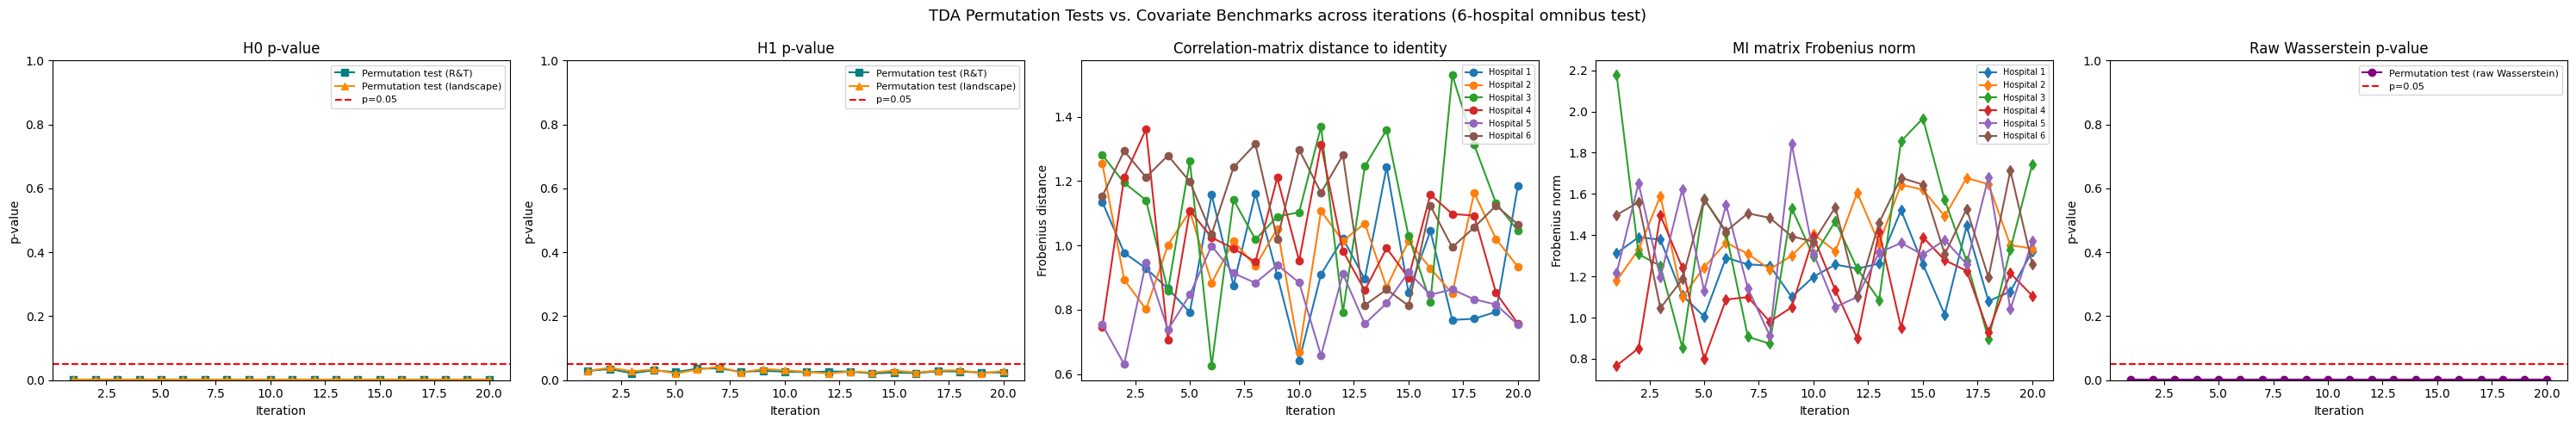

In [35]:
# Plot p-values (R&T and landscape permutation tests) and non-topological baselines (correlation distance, MI Frobenius norm,
# raw-covariate Wasserstein p-value) across iterations, for the 6-hospital omnibus test

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
iters = range(1, n_iterations + 1)

# Panel 0: H0 p-value
axes[0].plot(iters, results["H0_perm_pvalue"], marker="s", color="teal", label="Permutation test (R&T)")
axes[0].plot(iters, results["H0_landscape_perm_pvalue"], marker="^", color="darkorange", label="Permutation test (landscape)")
axes[0].axhline(0.05, color="red", linestyle="--", label="p=0.05")
axes[0].set_title("H0 p-value")
axes[0].set_ylabel("p-value")
axes[0].set_xlabel("Iteration")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

# Panel 1: H1 p-value
axes[1].plot(iters, results["H1_perm_pvalue"], marker="s", color="teal", label="Permutation test (R&T)")
axes[1].plot(iters, results["H1_landscape_perm_pvalue"], marker="^", color="darkorange", label="Permutation test (landscape)")
axes[1].axhline(0.05, color="red", linestyle="--", label="p=0.05")
axes[1].set_title("H1 p-value")
axes[1].set_ylabel("p-value")
axes[1].set_xlabel("Iteration")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

# Panel 2: correlation-matrix distance to identity, per hospital
corr_dist_by_hospital_series = {h: [d[h] for d in results["corr_dist"]] for h in hospitals}
for h in hospitals:
    axes[2].plot(iters, corr_dist_by_hospital_series[h], marker="o", label=h)
axes[2].set_title("Correlation-matrix distance to identity")
axes[2].set_ylabel("Frobenius distance")
axes[2].set_xlabel("Iteration")
axes[2].legend(fontsize=7)

# Panel 3: MI matrix Frobenius norm, per hospital
mi_frob_by_hospital_series = {h: [d[h] for d in results["mi_frob"]] for h in hospitals}
for h in hospitals:
    axes[3].plot(iters, mi_frob_by_hospital_series[h], marker="d", label=h)
axes[3].set_title("MI matrix Frobenius norm")
axes[3].set_ylabel("Frobenius norm")
axes[3].set_xlabel("Iteration")
axes[3].legend(fontsize=7)

# Panel 4: raw Wasserstein permutation p-value
axes[4].plot(iters, results["raw_wasserstein_pvalue"], marker="o", color="purple", label="Permutation test (raw Wasserstein)")
axes[4].axhline(0.05, color="red", linestyle="--", label="p=0.05")
axes[4].set_title("Raw Wasserstein p-value")
axes[4].set_ylabel("p-value")
axes[4].set_xlabel("Iteration")
axes[4].set_ylim(0, 1)
axes[4].legend(fontsize=8)

plt.suptitle("TDA Permutation Tests vs. Covariate Benchmarks across iterations (6-hospital omnibus test)", fontsize=13)
plt.tight_layout()
plt.show()

In [36]:
# Compute per-iteration mean/std of correlation distance and MI Frobenius norm across hospitals

corr_arr = np.array([[d[h] for h in hospitals] for d in results["corr_dist"]])  # shape (n_iter, n_hospitals)
mi_arr = np.array([[d[h] for h in hospitals] for d in results["mi_frob"]])

corr_mean, corr_std = corr_arr.mean(axis=1), corr_arr.std(axis=1)
mi_mean, mi_std = mi_arr.mean(axis=1), mi_arr.std(axis=1)

In [37]:
# Summarise mean, standard deviation, and % significant (p<0.05) for the R&T and landscape permutation tests into one results table
# Also includes the raw-covariate Wasserstein permutation test and the non-topological baselines
# (correlation-matrix distance, MI Frobenius norm), averaged across hospitals per iteration

corr_dist_mean_per_iter = [np.mean(list(d.values())) for d in results["corr_dist"]]
mi_frob_mean_per_iter = [np.mean(list(d.values())) for d in results["mi_frob"]]

summary = pd.DataFrame({
    "Metric": [
        "H0 p-value (permutation, R&T)",
        "H1 p-value (permutation, R&T)",
        "H0 p-value (permutation, landscape)",
        "H1 p-value (permutation, landscape)",
        "p-value (permutation, raw Wasserstein)",
        "Correlation-matrix distance (mean across hospitals)",
        "MI Frobenius norm (mean across hospitals)",
    ],
    "Mean": [
        np.mean(results["H0_perm_pvalue"]),
        np.mean(results["H1_perm_pvalue"]),
        np.mean(results["H0_landscape_perm_pvalue"]),
        np.mean(results["H1_landscape_perm_pvalue"]),
        np.mean(results["raw_wasserstein_pvalue"]),
        np.mean(corr_dist_mean_per_iter),
        np.mean(mi_frob_mean_per_iter),
    ],
    "Std": [
        np.std(results["H0_perm_pvalue"]),
        np.std(results["H1_perm_pvalue"]),
        np.std(results["H0_landscape_perm_pvalue"]),
        np.std(results["H1_landscape_perm_pvalue"]),
        np.std(results["raw_wasserstein_pvalue"]),
        np.std(corr_dist_mean_per_iter),
        np.std(mi_frob_mean_per_iter),
    ],
    "% significant (p<0.05)": [
        f"{np.mean(np.array(results['H0_perm_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['H1_perm_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['H0_landscape_perm_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['H1_landscape_perm_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['raw_wasserstein_pvalue']) < 0.05) * 100:.0f}%",
        "-",
        "-",
    ],
})
print(summary.to_string(index=False))


                                             Metric     Mean          Std % significant (p<0.05)
                      H0 p-value (permutation, R&T) 0.000999 2.168404e-19                   100%
                      H1 p-value (permutation, R&T) 0.027273 4.412600e-03                   100%
                H0 p-value (permutation, landscape) 0.000999 2.168404e-19                   100%
                H1 p-value (permutation, landscape) 0.028821 5.644798e-03                   100%
             p-value (permutation, raw Wasserstein) 0.000999 2.168404e-19                   100%
Correlation-matrix distance (mean across hospitals) 1.001546 5.243520e-02                      -
          MI Frobenius norm (mean across hospitals) 1.314840 9.866165e-02                      -
